In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.metrics import matthews_corrcoef, precision_score
from sklearn.model_selection import RandomizedSearchCV, train_test_split, StratifiedKFold, TimeSeriesSplit
from xgboost import XGBClassifier
import pickle
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
from hmmlearn.hmm import GaussianHMM

def get_data(ticker):
    
    df_orig = yf.Ticker(ticker).history(period="max", interval="1d", auto_adjust=True).reset_index()[['Date', 'Close', 'High', 'Low', 'Volume']]
    df_orig['Date'] = pd.to_datetime(df_orig['Date']).dt.strftime('%Y-%m-%d')
    
    return df_orig

def ma_features(df): 
    
    df = df.sort_values(by='Date', ascending=True)

    # =======================
    # Basic SMAs and Ratios
    # =======================
    for window in [5, 10, 25, 50, 100, 200]:
        
        df[f'SMA_{window}'] = df['Close'].rolling(window=window).mean()

        # Current close relativet to n_day high | max 1
        df[f'Close_Rel_Max{window}'] = (df['Close'] / df['High'].rolling(window=window).max()).round(2)
        # Current close relativet to n_day low | min 1
        df[f'Close_Rel_Min{window}'] = (df['Close'] / df['Low'].rolling(window=window).min()).round(2)

        if window in (50, 100, 200):
            df[f'num_days_{window}'] = 0
    
    for window in [50, 100, 200]:
        for i in range(1, len(df)):
            prev = df.loc[i - 1, f'num_days_{window}']
            price = df.loc[i, 'Close']
            sma = df.loc[i, f'SMA_{window}']
            if price > sma:
                df.loc[i, f'num_days_{window}'] = prev + 1 if prev >= 0 else 0
            elif price < sma:
                df.loc[i, f'num_days_{window}'] = prev - 1 if prev <= 0 else 0
            else:
                df.loc[i, f'num_days_{window}'] = 0

        #df[f'num_days_{window}'] = df[f'num_days_{window}'].apply(lambda x: int(5 * round(x / 5)))

    lag_periods = []#[50, 100, 150, 200]

    for lag in lag_periods:
        new_cols = {}
        for col in df.columns:
            if col.startswith('SMA_'):
                new_cols[f'{col}_Lag{lag}'] = (df[col] / df[col].shift(-lag)).round(2)

        df = pd.concat([df, pd.DataFrame(new_cols, index=df.index)], axis=1)
            
    for window in []: #[50, 100, 200]:
        for i in range(1, len(df)):
            prev = df.loc[i - 1, f'num_days_{window}']
            price = df.loc[i, 'Close']
            sma = df.loc[i, f'SMA_{window}']
            if price > sma:
                df.loc[i, f'num_days_{window}'] = prev + 1 if prev >= 0 else 0
            elif price < sma:
                df.loc[i, f'num_days_{window}'] = prev - 1 if prev <= 0 else 0
            else:
                df.loc[i, f'num_days_{window}'] = 0

        #df[f'num_days_{window}'] = df[f'num_days_{window}'].apply(lambda x: int(5 * round(x / 5)))

    # ============================
    # Relative Position Features
    # ============================
    def rows_since_max(x): return len(x) - x.argmax() - 1
    def rows_since_min(x): return len(x) - x.argmin() - 1

    for window in [10, 30, 60, 120, 240]:

        df[f'Rel_Max_{window}'] = (df['High'] / df['High'].rolling(window=window).max()).round(2)
        df[f'Rel_Min_{window}'] = (df['Low'] / df['Low'].rolling(window=window).min()).round(2)
        df[f'Max_{window}_Rows_Since'] = df['High'].rolling(window=window).apply(rows_since_max, raw=True)
        df[f'Min_{window}_Rows_Since'] = df['Low'].rolling(window=window).apply(rows_since_min, raw=True)

    for a, b in [(50, 100), (50, 200), (100, 200), (10, 25), (10, 50), (10, 100), (10, 200), (25, 50), (25, 100), (25, 200),
                (5, 10), (5, 25), (5,50)]:    
        df[f'{a}_SMA_{b}'] = (df[f'SMA_{a}'] / df[f'SMA_{b}']).round(2)

    def round_to_nearest_point05(x):
        return round(x * 20) / 20

    for window in [5, 10, 25, 50, 100, 200]:

        df[f'SMA_{window}'] = (df['Close'] / df[f'SMA_{window}']).round(2)
        #df[f'EMA_{window}'] = (df['Close'] / df[f'EMA_{window}']).round(2)

    return df

def rsi_macd_features(df):

    df = df.sort_values(by='Date', ascending=True)

    # RSI
    def RSI(data, period, diff):
        delta = data['Close'].diff(diff)
        gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
        RS = gain / loss
        return (100 - (100 / (1 + RS))).round(0)

    difs = [1, 3, 5]
    for dif in difs:
        df[f'RSI_14_{dif}'] = RSI(df, 14, dif)
        df[f'RSI_14_{dif}'] = RSI(df, 14, dif)
        df[f'RSI_14_{dif}'] = RSI(df, 14, dif)
        df[f'RSI_21_{dif}'] = RSI(df, 21, dif)
        df[f'RSI_21_{dif}'] = RSI(df, 21, dif)
        df[f'RSI_21_{dif}'] = RSI(df, 21, dif)

    # ================
    # MACD
    # ================
    ema_fast = df['Close'].ewm(span=12, adjust=False).mean()
    ema_slow = df['Close'].ewm(span=26, adjust=False).mean()
    df['MACD'] = (ema_fast - ema_slow).round(3)
    df['Signal_Line'] = df['MACD'].ewm(span=9, adjust=False).mean().round(3)
    df['MACD'] = (df['MACD'] / df['Close']).round(4)
    df['Signal_Line'] = (df['Signal_Line'] / df['Close']).round(4)

    # ================
    # Bollinger Bands
    # ================
    bb_mid = df['Close'].rolling(window=20).mean()
    bb_std = df['Close'].rolling(window=20).std()
    df['BB_Upper'] = (bb_mid + 2 * bb_std).round(3) / df['Close']
    df['BB_Lower'] = (bb_mid - 2 * bb_std).round(3) / df['Close']
    df['BB_Mid_raw'] = (bb_mid * bb_std / df['Close'])
    df['BB_Mid'] = ((df['BB_Mid_raw'] - df['BB_Mid_raw'].rolling(42).mean()) / df['BB_Mid_raw'].rolling(42).std()).round(3)

    return df

def volume(df):

    df = df.sort_values(by='Date', ascending=True)

    # ================
    # VOLUME
    # ================

    # OBV Core
    df['OBV'] = (np.sign(df['Close'].diff()) * df['Volume']).fillna(0).cumsum()

    # Momentum / Deviation
    windows = [5, 10]
    for w in windows:
        df[f'OBV_ROC{w}'] = df['OBV'].pct_change(periods=w).round(3)
        df[f'OBV_Z{w}'] = ((df['OBV'] - df['OBV'].rolling(w).mean()) / df['OBV'].rolling(w).std()).round(3)

    df['OBV'] = (df['OBV'] - df['OBV'].rolling(42).mean()) / df['OBV'].rolling(42).std()
    
    df['UpMask'] = df['Close'] > df['Close'].shift(1)
    df['DownMask'] = df['Close'] < df['Close'].shift(1)
    df['UpVolume'] = df['Volume'] * df['UpMask']
    df['DownVolume'] = df['Volume'] * df['DownMask']
    windows = [10, 25, 50, 100]
    #df = calculate_obv_volume_ratio(df, windows)
    z = 42
    for w in windows:
        up = df['UpVolume'].rolling(w).sum()
        down = df['DownVolume'].rolling(w).sum()

        ratio = up / down.replace(0, np.nan)
        ratio.fillna(0, inplace=True)
        ratio[up == 0] = 0  # More direct than re-rolling

        df[f'Vol_Ratio_{w}'] = ratio.round(3)
        df[f'Vol_Ratio_{w}'] = ((ratio - ratio.rolling(z).mean()) / ratio.rolling(z).std()).round(3)

    # Chaikin Money Flow (CMF)
    def CMF(data, period=20):
        mfm = ((data['Close'] - data['Low']) - (data['High'] - data['Close'])) / (data['High'] - data['Low'])
        mfm = mfm.replace([np.inf, -np.inf], 0).fillna(0)
        mfv = mfm * data['Volume']
        cmf = mfv.rolling(window=period).sum() / data['Volume'].rolling(window=period).sum()
        return cmf.round(3)
    
    df['CMF_20'] = CMF(df, 20)
    df['CMF_10'] = CMF(df, 10)
     
    # Volume Rate of Change (VROC)
    windows = [3, 5, 10]
    for w in windows:
        df[f'VROC_{w}'] = df['Volume'].pct_change(periods=w).round(3)

    # Normalized Volume Spike
    windows = [10, 20, 40]
    for w in windows:
        df[f'Vol_Spike_{w}'] = (df['Volume'] / df['Volume'].rolling(w).median()).round(3)

    # Accumulation/Distribution Line (ADL)
    mfm = ((df['Close'] - df['Low']) - (df['High'] - df['Close'])) / (df['High'] - df['Low'])
    mfm = mfm.replace([np.inf, -np.inf], 0).fillna(0)
    df['ADL'] = (mfm * df['Volume']).cumsum().round(3)
    df['ADL'] = (df['ADL'] - df['ADL'].rolling(42).mean()) / df['ADL'].rolling(42).std()

    return df

def atr_adx_vol(df):

    df = df.sort_values(by='Date', ascending=True)

    # ================
    # ATR
    # ================
    tr = pd.concat([
        df['High'] - df['Low'],
        abs(df['High'] - df['Close'].shift()),
        abs(df['Low'] - df['Close'].shift())
    ], axis=1).max(axis=1)
    windows = [7, 14, 21]
    for w in windows:
        df[f'ATR_{w}'] = tr.rolling(w).mean().round(1)
        df[f'ATR_{w}'] = (df[f'ATR_{w}'] - df[f'ATR_{w}'].rolling(42).mean()) / df[f'ATR_{w}'].rolling(42).std()

    # ================
    # ADX & DI
    # ================
    plus_dm = df['High'].diff()
    minus_dm = df['Low'].diff()
    plus_dm[plus_dm < 0] = 0
    minus_dm[minus_dm > 0] = 0

    tr = pd.concat([
        df['High'] - df['Low'],
        abs(df['High'] - df['Close'].shift(1)),
        abs(df['Low'] - df['Close'].shift(1))
    ], axis=1).max(axis=1)
    atr = tr.rolling(14).mean()

    plus_di = 100 * (plus_dm.ewm(alpha=1/14).mean() / atr)
    minus_di = abs(100 * (minus_dm.ewm(alpha=1/14).mean() / atr))
    dx = 100 * abs((plus_di - minus_di) / (plus_di + minus_di))
    adx = dx.rolling(14).mean()

    df['plus_DI'] = plus_di.round(0)
    df['minus_DI'] = minus_di.round(0)
    df['ADX'] = adx.round(0)

    # ================
    # Volatility
    # ================
    vol_5 = df['Close'].pct_change().rolling(window=5).std().round(3)
    vol_10 = df['Close'].pct_change().rolling(window=10).std().round(3)
    vol_25 = df['Close'].pct_change().rolling(window=25).std().round(3)

    new_cols = {
        'vol_5': vol_5,
        'vol_10': vol_10,
        'vol_25': vol_25,
        'Price_Vol_Ratio_5': (df['Close'] / vol_5).round(3),
        'Price_Vol_Ratio_10': (df['Close'] / vol_10).round(3),
        'Price_Vol_Ratio_25': (df['Close'] / vol_25).round(3)
    }

    df = pd.concat([df, pd.DataFrame(new_cols, index=df.index)], axis=1)

    # Z-score normalize each
    for w in [5, 10, 25]:
        vol_col = f'vol_{w}'
        df[f'{vol_col}'] = (
            (df[vol_col] - df[vol_col].rolling(42).mean()) /
            df[vol_col].rolling(42).std()
        ).replace([np.inf, -np.inf], 0).fillna(0).round(3)

        pvol_col = f'Price_Vol_Ratio_{w}'
        df[f'{pvol_col}'] = (
            (df[pvol_col] - df[pvol_col].rolling(42).mean()) /
            df[pvol_col].rolling(42).std()
        ).replace([np.inf, -np.inf], 0).fillna(0).round(3)

    return df

def vix_skew(df):

    df = df.sort_values(by='Date', ascending=True)

    # ================
    # VIX External Data
    # ================
    vix_data = yf.Ticker("^VXN").history(period="max", interval="1d", auto_adjust=True)
    # Resetting the index will turn the Date index into a column
    vix_data = vix_data.reset_index()[['Date', 'Close', 'High', 'Low', 'Volume']]
    # Convert the Date column to 'YYYY-MM-DD' format (if not already)
    vix_data['Date'] = pd.to_datetime(vix_data['Date']).dt.strftime('%Y-%m-%d')
    vix_data['VIX'] = vix_data['Close']

    ['VIX_5_change', 'VIX_crossover', 'VIX_1_change']
    # Convert the Date column to 'YYYY-MM-DD' format (if not already)
    vix_data = vix_data.sort_index(ascending=True)
    vix_data['VIX_rolling_std'] = vix_data['VIX'].rolling(window=5).std().round(1)
    vix_data['VIX_short_ma'] = vix_data['VIX'].rolling(window=3).mean()
    vix_data['VIX_long_ma'] = vix_data['VIX'].rolling(window=20).mean()
    vix_data['VIX_crossover'] = np.where(vix_data['VIX_short_ma'] > vix_data['VIX_long_ma'], 1, -1)
    vix_data['VIX_5_change'] = vix_data['VIX'].pct_change(periods=5).round(3)
    vix_data['VIX_1_change'] = vix_data['VIX'].pct_change(periods=1).round(3)
    vix_data['VIX_10_change'] = vix_data['VIX'].pct_change(periods=10).round(3)

    df = pd.merge(df, vix_data[['Date', 'VIX', 'VIX_rolling_std', 'VIX_crossover', 'VIX_5_change', 'VIX_1_change', 'VIX_10_change']],
                    on='Date', how='left')
    
    vix_cols = [col for col in df.columns if col.startswith('VIX')]
    df[vix_cols] = df[vix_cols].ffill()
    
    # ================
    # SKEW External Data
    # ================
    skew_data = yf.Ticker("^VXN").history(period="max", interval="1d", auto_adjust=True)
    # Resetting the index will turn the Date index into a column
    skew_data = skew_data.reset_index()[['Date', 'Close', 'High', 'Low', 'Volume']]
    # Convert the Date column to 'YYYY-MM-DD' format (if not already)
    skew_data['Date'] = pd.to_datetime(skew_data['Date']).dt.strftime('%Y-%m-%d')
    skew_data['skew'] = skew_data['Close']

    ['skew_5_change', 'skew_crossover', 'skew_1_change']
    # Convert the Date column to 'YYYY-MM-DD' format (if not already)
    skew_data = skew_data.sort_index(ascending=True)
    skew_data['skew_rolling_std'] = skew_data['skew'].rolling(window=5).std().round(1)
    skew_data['skew_short_ma'] = skew_data['skew'].rolling(window=3).mean()
    skew_data['skew_long_ma'] = skew_data['skew'].rolling(window=20).mean()
    skew_data['skew_crossover'] = np.where(skew_data['skew_short_ma'] > skew_data['skew_long_ma'], 1, -1)
    skew_data['skew_5_change'] = skew_data['skew'].pct_change(periods=5).round(3)
    skew_data['skew_1_change'] = skew_data['skew'].pct_change(periods=1).round(3)
    skew_data['skew_10_change'] = skew_data['skew'].pct_change(periods=10).round(3)

    df = pd.merge(df, skew_data[['Date', 'skew', 'skew_rolling_std', 'skew_crossover', 'skew_5_change', 'skew_1_change', 'skew_10_change']],
                    on='Date', how='left')
    
    skew_cols = [col for col in df.columns if col.startswith('skew')]
    df[skew_cols] = df[skew_cols].ffill()

    return df

def experimental_slop(df):

    df = df.sort_values(by='Date', ascending=True)
    
    # ================
    # Experimental Features
    # ================
    # CCI (Commodity Channel Index)
    tp = (df['High'] + df['Low'] + df['Close']) / 3
    ma = tp.rolling(window=14).mean()
    md = tp.rolling(window=14).apply(lambda x: np.mean(np.abs(x - np.mean(x))))
    df['CCI_14'] = ((tp - ma) / (0.015 * md)).round(3)

    # Williams %R
    highest_high = df['High'].rolling(window=14).max()
    lowest_low = df['Low'].rolling(window=14).min()
    df['Williams_%R_14'] = ((highest_high - df['Close']) / (highest_high - lowest_low) * -100).round(3)

    # Z-scores
    zs = [5, 10, 25, 50]
    for z in zs:
        df[f'Zscore_{z}'] = ((df['Close'] - df['Close'].rolling(z).mean()) / df['Close'].rolling(z).std()).round(3)
        df[f'Zscore_{z}'] = df[f'Zscore_{z}'].replace([np.inf, -np.inf], np.nan)

    def generate_slope_features(df):
        slope_windows = [10, 25, 50]

        slope_targets = ['Close']

        def fast_slope_normalized(series, w):
            x = np.arange(w)
            x_mean = x.mean()
            denominator = ((x - x_mean) ** 2).sum()
            return series.rolling(w).apply(
                lambda y: ((x - x_mean) * ((y / y[0]) - (y / y[0]).mean())).sum() / denominator
                if y[0] != 0 else np.nan,
                raw=True
            )

        slope_features = {}
        for w in slope_windows:
            for var in slope_targets:
                if var in df.columns:
                    slope_features[f'{var}_slope{w}'] = fast_slope_normalized(df[var], w).round(5)

        return pd.concat([df, pd.DataFrame(slope_features, index=df.index)], axis=1)

    # Usage
    df = generate_slope_features(df)

    return df

def generate_returns(df, returns):

    def add_column_based_on_future_value(df, days):

        df = df.sort_values(by='Date', ascending=True)
        future_return = (df['Close'].shift(-days) - df['Close']) / df['Close']
        df[f'Return%_{days}'] = (future_return * 100).round(1) 
        df[f'Return_{days}'] = (future_return > 0).astype(int)
        
        past_return = (df['Close'] - df['Close'].shift(days)) / df['Close']
        df[f'Past_Return_{days}'] = (past_return > 0).astype(int)

        return df

    df_returns = df.copy()

    for r in returns:
    
        df_returns = add_column_based_on_future_value(df_returns, r)

    return df_returns


def print_metrics(metrics):
        for thresh, metric_values in metrics.items():
            i = 1
            #print(f"{thresh}: {metric_values}")
  
def optimize_splits_new(df_indicators, df_predict, thresh, opt, test_size, name, cv_type, return_metrics=False):
    
    def train(model, param_grid, X_train, y_train, X_test, y_test, X_tune, y_tune, opt, thresh, iter, name, cv, cv_type):

        model.set_params(n_jobs=1)
        random_search = RandomizedSearchCV(
            estimator=model,
            param_distributions=param_grid,
            scoring=opt,
            cv=cv,
            n_jobs=-1,
            n_iter=iter,
            random_state=42
        )
        
        if cv_type == 'rs':
            random_search.fit(X_train, y_train, eval_set=[(X_tune, y_tune)], verbose=False)
        else: random_search.fit(X_train, y_train, verbose=False)
        best_model = random_search.best_estimator_
        y_prob = best_model.predict_proba(X_test)
        postot = y_test.sum()
        negtot = len(y_test) - y_test.sum()

        metrics = {}
        for t in thresh:
            y_pred_thresh = (y_prob[:, 1] > t).astype(int)
            y_pred_thresh[y_prob[:, 0] > t] = 0
            filtered_indices = (y_prob[:, 1] > t) | (y_prob[:, 0] > t)
            actpos = int(y_test.sum())        # actual positives
            actneg = int(len(y_test) - actpos)  # actual negatives

            if filtered_indices.sum() > 0:
                y_test_valid = y_test[filtered_indices]
                y_pred_valid = y_pred_thresh[filtered_indices]
                posprec = round(precision_score(y_test_valid, y_pred_valid, pos_label=1, zero_division=0), 2)
                negprec = round(precision_score(y_test_valid, y_pred_valid, pos_label=0, zero_division=0), 2)
                predpos = sum(y_pred_valid == 1)
                predneg = sum(y_pred_valid == 0)
                posrec = round(posprec * predpos / postot, 2) if postot else 0
                negrec = round(negprec * predneg / negtot, 2) if negtot else 0
                pos_denom = (2*posrec)+(1*posprec)
                neg_denom = (2*negrec)+(1*negprec)
                posfb = round((3*posprec*posrec)/pos_denom, 2) if pos_denom else 0
                negfb = round((3*negprec*negrec)/neg_denom, 2) if neg_denom else 0
                metrics[t] = {
                    "Name": name,
                    "PAC": actpos,
                    "PPC": predpos,
                    "NAC": actneg,
                    "NPC": predneg,
                    "PP": posprec,
                    "PR": posrec,
                    "NP": negprec,
                    "NR": negrec,
                    "PosFb": posfb,
                    "NegFb": negfb,
                    "Retained": round(((predpos + predneg) / len(y_test)),2)
                }
                metrics[t] = {k: np.nan_to_num(v, nan=0.0) for k, v in metrics[t].items()}
            
        return metrics, best_model
    
    iter = 50

    if cv_type == 'rs':
        
        cv = StratifiedKFold(n_splits=6, shuffle=True, random_state=42)
    
        X_test = df_indicators.iloc[:test_size].copy()
        y_test = df_predict.iloc[:test_size].copy()
        
        df_indicators = df_indicators.iloc[test_size:].sort_index(ascending=True).copy()
        df_predict = df_predict.iloc[test_size:].sort_index(ascending=True).copy()
        X_train, X_tune, y_train, y_tune = train_test_split(df_indicators, df_predict, test_size=0.2, random_state=42, shuffle=True)

        counts = y_train.value_counts()
        negf = counts.get(0, 0)
        posf = counts.get(1, 1)  # prevent division by zero
        scale_pos_weight = negf / posf

        xgboost_hyperparameters = {
            #'scale_pos_weight': [scale_pos_weight],
            'max_depth': [3, 6, 9],
            'learning_rate': [0.01, 0.05],    # Lower rates
            'min_child_weight': [6, 10],   # More conservative splits
            'subsample': [0.7, 0.8, 0.9],     
            'colsample_bytree': [0.75, 0.85], 
            'colsample_bylevel': [0.7, 0.8],
            'colsample_bynode': [0.7, 0.8],    
            'gamma': [0.3, 0.5],         
            'alpha': [0.5, 1.0], 
            'lambda': [10, 15],            
            'n_estimators': [200, 400, 600], 
            'early_stopping_rounds': [10]
            }
    
    else: 
        
        cv = TimeSeriesSplit(n_splits=6)

        X_test = df_indicators.iloc[:test_size].copy()
        y_test = df_predict.iloc[:test_size].copy()
        
        X_train = df_indicators.iloc[test_size:].sort_index(ascending=True).copy()
        y_train = df_predict.iloc[test_size:].sort_index(ascending=True).copy()
        X_tune = None
        y_tune = None

        xgboost_hyperparameters = {
            'max_depth': [3, 6, 9],
            'learning_rate': [0.01, 0.05],    # Lower rates
            'min_child_weight': [10],   # More conservative splits
            'subsample': [0.7, 0.8, 0.9],     
            'colsample_bytree': [0.75, 0.85], 
            'colsample_bylevel': [0.7, 0.8],
            'colsample_bynode': [0.7, 0.8],    
            'gamma': [0.3, 0.5],         
            'alpha': [0.5, 1.0], 
            'lambda': [10, 15],            
            'n_estimators': [200, 400], 
            }
    
    xg_metrics, best_xg_model = train(XGBClassifier(random_state=42), xgboost_hyperparameters, X_train, y_train, X_test, y_test, 
                                      X_tune, y_tune, opt, thresh, iter, name, cv, cv_type)

    #print_metrics(xg_metrics)

    if return_metrics:
        return best_xg_model, xg_metrics
    else:
        #print_metrics(xg_metrics)
        return best_xg_model, best_score

def add_run(metrics, metrics_df, df_ph):

    # convert to DataFrame and include threshold as a column
    df_run = pd.DataFrame.from_dict(metrics, orient='index').reset_index().rename(columns={'index': 'Threshold'})
    df_run['Start_Date'] = df_ph['Date'].iloc[test_size]
    df_run['End_Date'] = df_ph['Date'].iloc[0]
    df_run['LB'] = lb

    # then append to a cumulative DataFrame
    try:
        metrics_df = pd.concat([metrics_df, df_run], ignore_index=True)
    except NameError:
        metrics_df = df_run.copy()

    # PosFb: if PAC==0 and PPC==0, set to 1, else keep current
    metrics_df['PosFb'] = np.where((metrics_df['PAC'] == 0) & (metrics_df['PPC'] == 0), 1, metrics_df['PosFb'])

    # NegFb: if NAC==0 and NPC==0, set to 1, else keep current
    metrics_df['NegFb'] = np.where((metrics_df['NAC'] == 0) & (metrics_df['NPC'] == 0), 1, metrics_df['NegFb'])

    return metrics_df

def visualize_performance(metrics_df):
    metrics_df = metrics_df.copy()
    metrics_df["Actual_Distribution"] = (
        metrics_df["PAC"] / (metrics_df["PAC"] + metrics_df["NAC"])
    ).round(2)

    cols = ["PosFb", "NegFb"]

    for col in cols:
        # include all challengers dynamically
        df_vis = metrics_df[metrics_df["Name"].str.contains("Incumbent|Challenger", case=False, na=False)].copy()
        df_vis["Start_Date"] = pd.to_datetime(df_vis["Start_Date"])

        # one row per (Start_Date, Name)
        df_plot = (
            df_vis.sort_values("Start_Date")
                .groupby(["Start_Date", "Name"], as_index=False)
                .agg({col: "mean", "Actual_Distribution": "first"})
        )

        fig, ax = plt.subplots(figsize=(12, 4))

        # plot one line per Name (handles unlimited challengers)
        for name, g in df_plot.groupby("Name"):
            ax.plot(g["Start_Date"], g[col], marker="o", label=name)

        # plot Actual_Distribution on same axis
        actual = (
            df_plot.drop_duplicates("Start_Date")
                .set_index("Start_Date")["Actual_Distribution"]
        )
        ax.plot(actual.index, actual.values, linestyle="--", linewidth=2,
                color="black", label="Actual Distribution")

        # format axes
        ax.set_xlabel("Start Date")
        ax.set_ylabel(col)
        ax.set_ylim(-0.05, 1.05)  # y-axis range
        plt.xticks(rotation=45)   # rotate x labels

        ax.legend(title="Name", bbox_to_anchor=(1.05, 1), loc="upper left")
        plt.title(f"{col} by Start Date (lines per Name) with Actual Distribution")
        plt.tight_layout()
        plt.show()

def perm_cols(perm_df):

    group = perm_df.copy()
    group["drop_flag"] = group["importance_mean"] <= 0.01

    total = len(group)
    retained = (~group["drop_flag"]).sum()
    min_retained = min(int(np.ceil(total * 0.45)), 10)

    if retained < min_retained:
        top_feats = group.sort_values(by="importance_mean", ascending=False).head(min_retained)["feature"]
        group["drop_flag"] = ~group["feature"].isin(top_feats)

    final_df = group[~group["drop_flag"]]
    
    return final_df['feature'].to_list()

def run(filtered, prod_cols, ret_col, lb, cv_type, name, metrics_df):
    
    df_model = filtered[prod_cols + [ret_col]].dropna()
    
    df_indicators = df_model[prod_cols]
    df_indicators = df_indicators.replace([np.inf, -np.inf], 0)
    df_predict = df_model[ret_col]

    if name == 'Incumbent':
        print(f"Run {i+1} of {runs} | LB: {lb} | {filtered['Date'].iloc[test_size]} - {filtered['Date'].iloc[0]}")

    best_xg_model, metrics = optimize_splits_new(df_indicators, df_predict, thresh, opt, 
                                                    test_size, name, cv_type, return_metrics=True)

    # Then apply PI
    X_test = df_indicators.iloc[:perm_size].copy()
    y_test = df_predict.iloc[:perm_size].copy()

    perm = permutation_importance(best_xg_model, X_test, y_test, n_repeats=100, random_state=None, n_jobs=-1)

    # Organize into a DataFrame
    perm_df = pd.DataFrame({
        'feature': df_indicators.columns,
        'importance_mean': perm.importances_mean,
        'importance_std': perm.importances_std,
        'horizon': r,
        'split': 'Temporal',
        'Start': df_ph['Date'].iloc[test_size],
        'End': df_ph['Date'].iloc[0]
    })
    
    # Extract top indicators
    pi_cols = perm_cols(perm_df)
    df_indicators = df_model[pi_cols]

    # Rerun for trimed indicator set
    best_xg_model, metrics = optimize_splits_new(df_indicators, df_predict, thresh, opt, 
                                                    test_size, name, cv_type, return_metrics=True)

    # Save run results
    metrics_df = add_run(metrics, metrics_df, df_ph)

    return metrics_df

# Challenger - Incumbent Logic

Run 1 of 10 | LB: 9 | 2025-10-14 - 2025-10-30
Run 2 of 10 | LB: 9 | 2025-09-26 - 2025-10-14
Run 3 of 10 | LB: 9 | 2025-09-09 - 2025-09-26
Run 4 of 10 | LB: 9 | 2025-08-21 - 2025-09-10
Run 5 of 10 | LB: 9 | 2025-08-06 - 2025-08-22
Run 6 of 10 | LB: 9 | 2025-07-17 - 2025-08-06
Run 7 of 10 | LB: 9 | 2025-07-01 - 2025-07-21
Run 8 of 10 | LB: 9 | 2025-06-12 - 2025-07-02
Run 9 of 10 | LB: 9 | 2025-05-28 - 2025-06-13
Run 10 of 10 | LB: 9 | 2025-05-08 - 2025-05-28


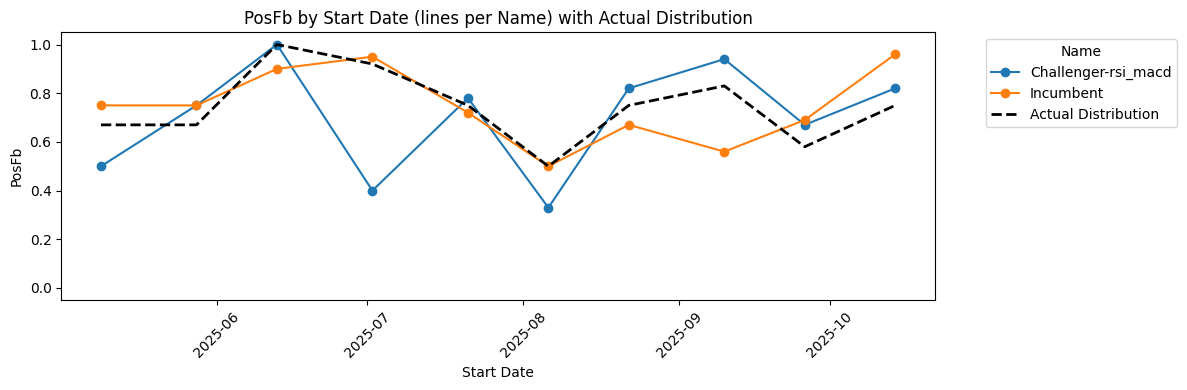

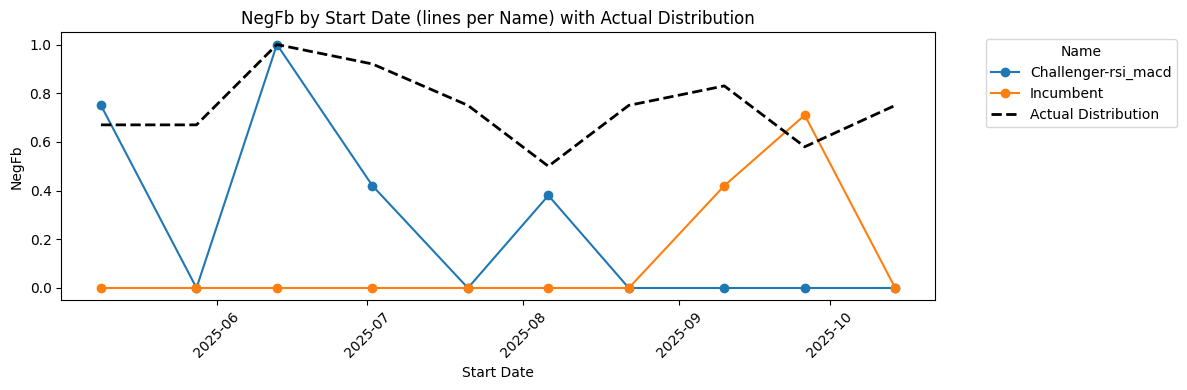

In [ ]:
ticker = 'QQQ'
thresh = [.55] # minimum confidence by model for predictions to be included
results = [] # for storing performance of single run
returns = [5] # list of time horizons to test
test_size = 12 # used for size of test set, default is 10-20
lbs = [9] # lookback years for training data, default is 8
eval = ['N'] # Can be Y or N, Y means use an eval set with optimize_splits_new
metrics_df = pd.DataFrame() # initialize df for storing performance of multiple runs
all_perm_dfs = [] # stores results of permutation importance for each run
perm_size = 245 # size of permutation importance 
offset_size = test_size # if doing multiple time series, this value determines the step size
runs = 10 # number of runs to do
opt = 'matthews_corrcoef' # evaluation metric, preferred is matthews_corrcoef

df_orig = get_data(ticker) # extract pricing data
df_returns = generate_returns(df_orig, returns) # generate target variable

exclude = {'Date', 'Close', 'High', 'Low', 'Volume'}
df_incumbent = ma_features(df_orig)
incumbent_cols = [c for c in df_incumbent.columns if c not in exclude]
df_challenger1 = rsi_macd_features(df_orig)
challenger1_cols = [c for c in df_challenger1.columns if c not in exclude]
df_challenger2 = volume(df_orig)
challenger2_cols = [c for c in df_challenger2.columns if c not in exclude]
df_challenger3 = atr_adx_vol(df_orig)
challenger3_cols = [c for c in df_challenger3.columns if c not in exclude]
df_challenger4 = vix_skew(df_orig)
challenger4_cols = [c for c in df_challenger4.columns if c not in exclude]
df_challenger5 = experimental_slop(df_orig)
challenger5_cols = [c for c in df_challenger5.columns if c not in exclude]

challengers = [df_challenger1, df_challenger2, df_challenger3, df_challenger4, df_challenger5]

# merge returns and features table into one df
df_merged = pd.merge(df_incumbent, df_returns[[col for col in df_returns.columns if col.startswith('Return')] + ['Date']], on='Date') 

# merge challengers, skipping duplicates
for challenger in challengers:
    new_cols = [c for c in challenger.columns if c not in df_merged.columns or c == 'Date']
    df_merged = pd.merge(df_merged, challenger[new_cols], on='Date')

df = df_merged.sort_values('Date', ascending=False).copy()  # newest first

for r in returns:

    for i in range(runs): # number of runs to do

        offset = max(i * offset_size, 0) # step size for each run
        
        for lb in lbs:             

            df_ph = df.iloc[offset : offset + 245 * lb, :].iloc[r:].copy()  # 245 records is ~1 year of data
            ret_col = f"Return_{r}"
            ret_pct_col = f"Return%_{r}"

            rets = df_ph[ret_pct_col]
            neg, pos = rets[rets < 0], rets[rets > 0]

            neg_cut = neg.nlargest(max(1, int(len(neg) * 0.05))).min()
            pos_cut = pos.nsmallest(max(1, int(len(pos) * 0.05))).max()
            filtered = df_ph[(rets < neg_cut) | (rets > pos_cut)].copy()
            
            #==== Incumbent Run ====#
            # First run for entire indicator set
            cv_type = 'temporal' # use rs for random split
            name = 'Incumbent'
            metrics_df = run(filtered, incumbent_cols, ret_col, lb, cv_type, name, metrics_df)

            #==== Challenger 1 Run ====#
            # First run for entire indicator set
            cv_type = 'temporal' # use rs for random split
            name = 'Challenger-rsi_macd'
            metrics_df = run(filtered, challenger1_cols, ret_col, lb, cv_type, name, metrics_df)
            
            """
            #==== Challenger 2 Run ====#
            # First run for entire indicator set
            cv_type = 'temporal' # use rs for random split
            name = 'Challenger-volume'
            metrics_df = run(filtered, challenger2_cols, ret_col, lb, cv_type, name, metrics_df)
            

            #==== Challenger 3 Run ====#
            # First run for entire indicator set
            cv_type = 'temporal' # use rs for random split
            name = 'Challenger-atr_adx'
            metrics_df = run(filtered, challenger3_cols, ret_col, lb, cv_type, name, metrics_df)

            #==== Challenger 4 Run ====#
            # First run for entire indicator set
            cv_type = 'temporal' # use rs for random split
            name = 'Challenger-vix_skew'
            metrics_df = run(filtered, challenger4_cols, ret_col, lb, cv_type, name, metrics_df)

            #==== Challenger 5 Run ====#
            # First run for entire indicator set
            cv_type = 'temporal' # use rs for random split
            name = 'Challenger-exp_slope'
            metrics_df = run(filtered, challenger5_cols, ret_col, lb, cv_type, name, metrics_df)
            """
 
visualize_performance(metrics_df)

# Regimes

- Hidden Markov Models
- Volatility Quintiles

In [ ]:
# 1) HMM
df_hmm = df_orig[['Close']].sort_index(ascending=True).copy()
shift = 1
#df_hmm['ref'] = df_hmm['Close'].shift(shift)
#df_hmm['%'] = df_hmm['Close'] / df_hmm['Close'].shift(shift) - 1
df_hmm['logr_5'] = np.log(abs(df_hmm['Close'] / df_hmm['Close'].shift(shift)))

min_obs = 250
max_obs = 250
r = df_hmm.iloc[len(df_hmm)-4000:, 1:]
n_states=3

states = pd.Series(index=r.index, dtype="int64")
model = GaussianHMM(n_components=n_states, covariance_type="diag", n_iter=200)
# expanding walk-forward
for i in range(min_obs, len(r)):
    print(i)
    start = max(0, i - max_obs)
    x = r.iloc[start:i].values.reshape(-1, 1)
    model.fit(x)
    proba = model.predict_proba(x)[-1]
    states.iloc[i] = proba.argmax()

# 2) Volatility regime
df_rv = df_orig[['Close']].sort_index(ascending=True).copy()
shift = 3
df_rv['logr_5'] = np.log(abs(df_rv['Close'] / df_rv['Close'].shift(shift)))

r = df_rv['logr_5']
rv = r.rolling(14).std()
vol_rank = rv.rolling(252).apply(lambda x: x.rank(pct=True).iloc[-1], raw=False)
vol_regime_3_14_252 = pd.cut(vol_rank, bins=[-1, 0.25, 0.5, 0.75, 1.01], labels=[0, 1, 2, 3])